In [76]:
%matplotlib inline
import pandas as pd
import numpy as np

import mplfinance as mpl 
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
from database_query import get_price_data, get_symbols_with_pd

In [85]:
data = get_price_data(get_symbols_with_pd(), date_range='2024-1-31::2024-11-30', default_cols=['close'])
data.close = data.close.astype('float64')
data.set_index('price_date', inplace=True)

data = data.pivot(columns=['ticker']).dropna()
data

close                                              \
ticker                   AAPL       AMD    CSCO    GOOG     INTC     JNPR   
price_date                                                                  
2024-01-31 14:16:00  187.0600  164.5000  52.200  144.40  42.4800  37.1900   
2024-01-31 14:28:00  186.9100  165.2500  51.900  145.05  42.5700  37.2100   
2024-01-31 14:30:00  186.2900  165.2300  51.660  144.65  42.5915  37.1800   
2024-01-31 14:31:00  186.0400  164.6570  51.555  145.51  42.4000  37.1399   
2024-01-31 14:32:00  186.0701  164.5101  51.585  144.57  42.4400  37.1600   
...                       ...       ...     ...     ...      ...      ...   
2024-11-29 17:56:00  237.4779  137.1900  59.105  170.53  24.0450  35.9000   
2024-11-29 17:57:00  237.4800  137.1600  59.170  170.60  24.0250  35.9250   
2024-11-29 17:58:00  237.4750  137.1700  59.230  170.55  24.0300  35.9300   
2024-11-29 17:59:00  237.3400  137.2000  59.220  170.56  24.0500  35.9400   
2024-11-29 18:00:00  237.7000  137.1500  58.940  170.49  24.0200  35.9200   

                                                                     
ticker                   META    MSFT      NFLX      NVDA      TSLA  
price_date                                                           
2024-01-31 14:16:00  388.9900  407.05  561.0000  614.8900  186.7000  
2024-01-31 14:28:00  388.6500  406.93  562.0000  613.7000  186.6800  
2024-01-31 14:30:00  389.6100  410.77  564.4100  617.6375  186.4250  
2024-01-31 14:31:00  391.7000  409.34  566.5300  617.4800  186.9400  
2024-01-31 14:32:00  393.2350  408.74  567.6100  617.5550  188.0883  
...                       ...     ...       ...       ...       ...  
2024-11-29 17:56:00  574.6050  423.95  887.1777  138.5400  344.3800  
2024-11-29 17:57:00  574.2950  423.91  886.2900  138.4050  344.4701  
2024-11-29 17:58:00  574.3001  423.84  886.7700  138.3750  344.6900  
2024-11-29 17:59:00  574.2100  423.46  886.7500  138.2800  345.1500  
2024-11-29 18:00:00  574.1000  424.38  886.6100  138.3000  345.8385  

[77270 rows x 11 columns]

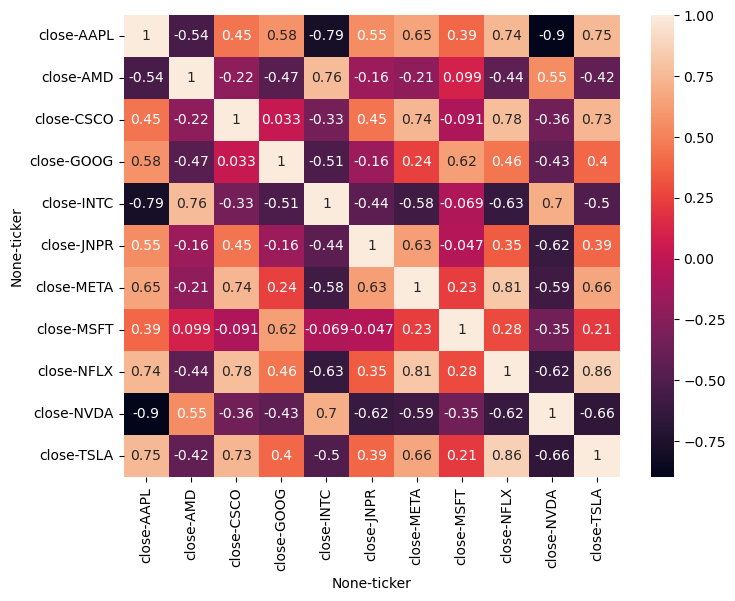

In [86]:
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True)
plt.show()

In [56]:
s1, s2 = 'NFLX', 'CSCO'
stock_1, stock_2 = data.close[s1], data.close[s2]
spread = stock_1 - stock_2

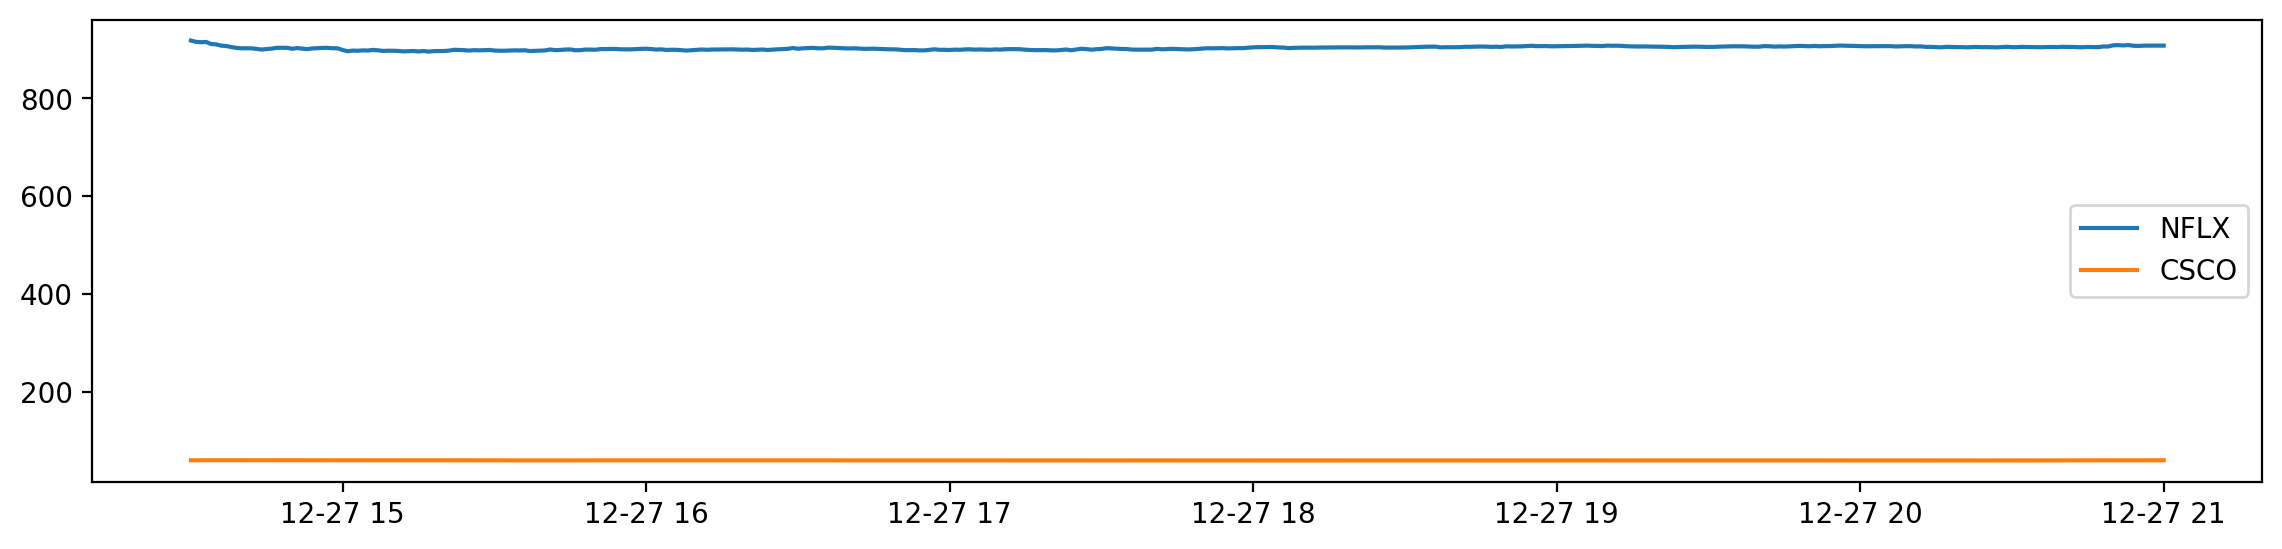

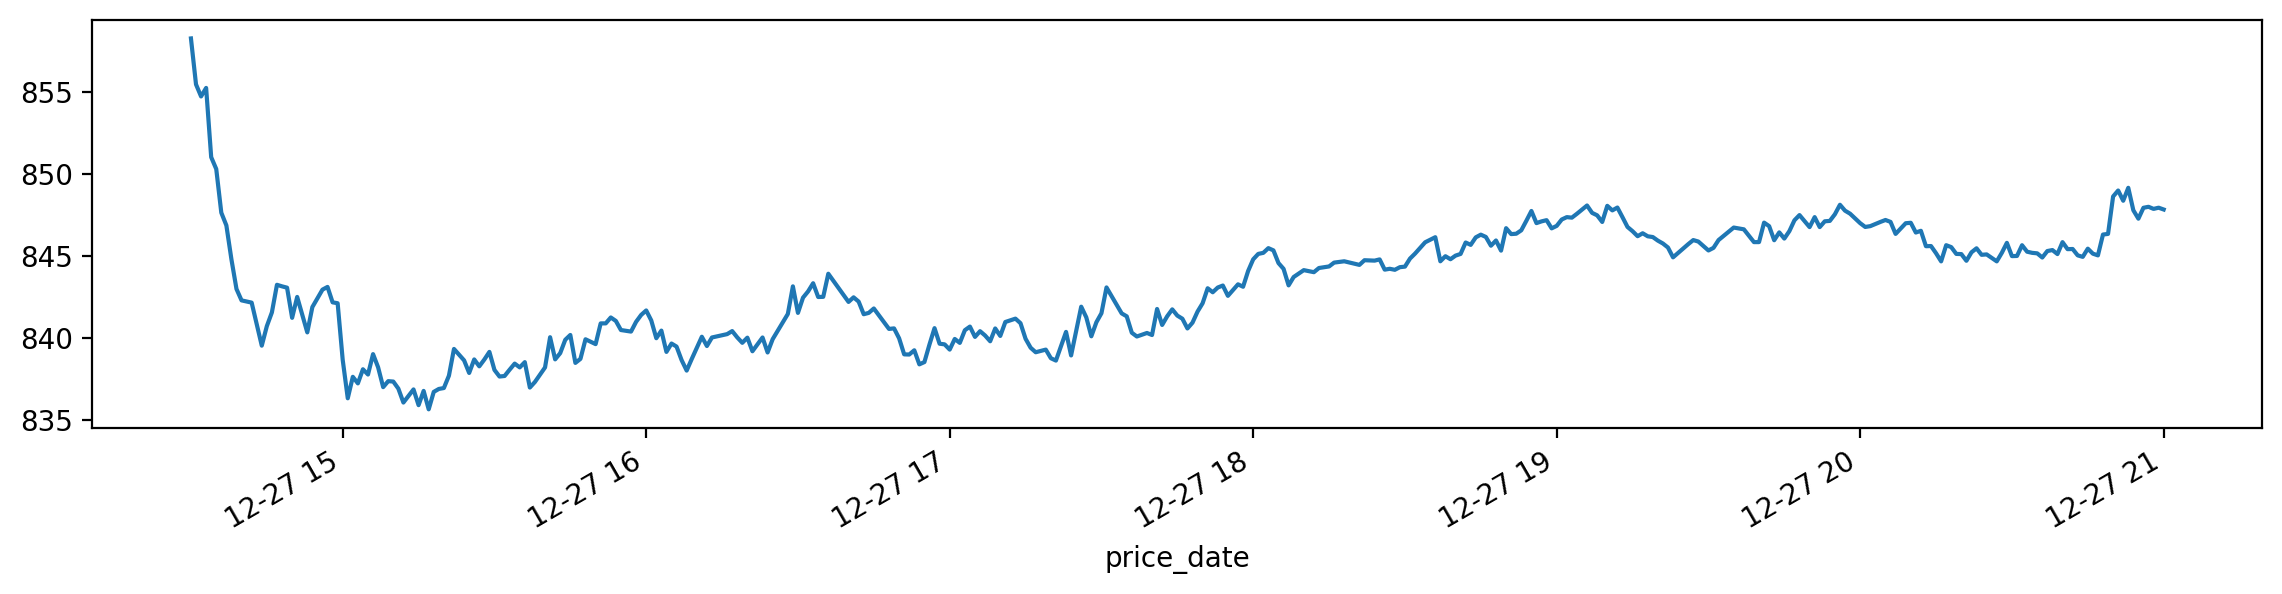

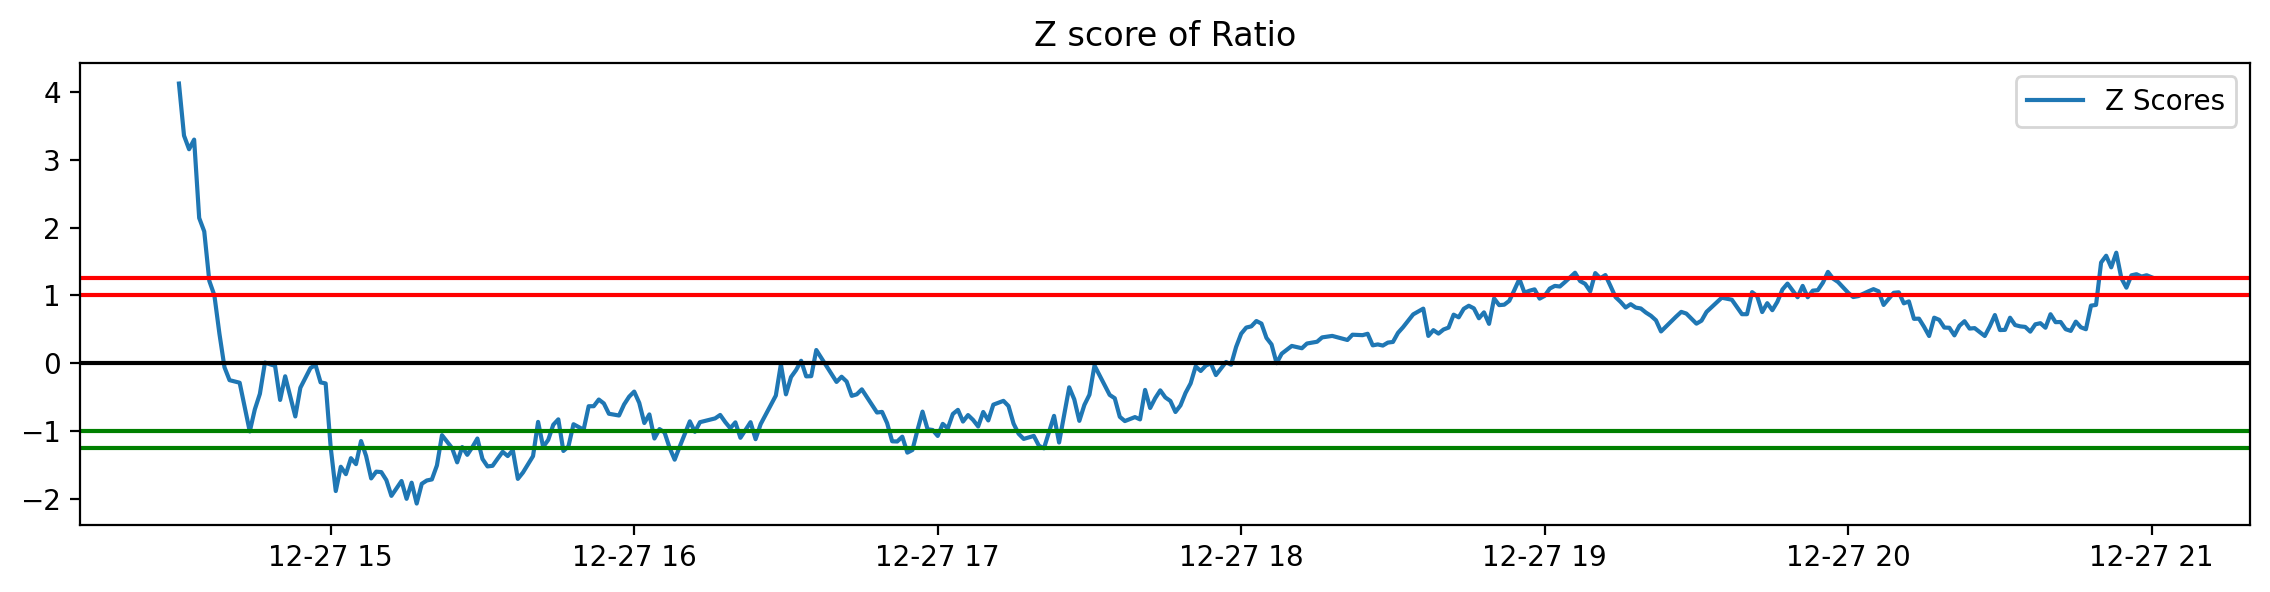

In [57]:
figs=(14,3)
plt.figure(figsize = figs, dpi=200)
plt.plot(stock_1, label=s1)
plt.plot(stock_2, label=s2)
plt.legend()
plt.show()

plt.figure(figsize = figs, dpi=200)
spread.plot()
plt.show()

plt.figure(figsize = figs, dpi=200)
zscore = (spread-spread.mean())/spread.std()
plt.plot(zscore, label = "Z Scores")
plt.axhline(zscore.mean(), color = 'black')
plt.axhline(1.0, color='red') # Setting the upper and lower bounds to be the z score of 1 and -1 (1/-1 standard deviation)
plt.axhline(1.25, color='red') # 95% of data will lie between these bounds.
plt.axhline(-1.0, color='green') # 68% of data will lie between these bounds.
plt.axhline(-1.25, color='green') # 95% of data will lie between these bounds.
plt.legend(loc = 'best')
plt.title('Z score of Ratio')
plt.show()

In [58]:
import statsmodels.tsa.stattools as ts 
from statsmodels.tsa.stattools import adfuller

In [59]:
result = ts.coint(stock_1, stock_2)
result

(-3.409454861652474,
 0.041311125745379845,
 array([-3.92884534, -3.35410686, -3.05691093]))

In [60]:
for i in [stock_1, stock_2, spread, stock_1/stock_2]:
    print(f"{adfuller(i)}")

(-3.4184311331673025, 0.010346374546159423, 1, 340, {'1%': -3.4497304638968043, '5%': -2.8700785273763487, '10%': -2.571319005190311}, 732.3652220342543)
(-1.2620585262113235, 0.6463469856107622, 0, 341, {'1%': -3.449673193310592, '5%': -2.8700533746644323, '10%': -2.5713055939491403}, -1401.3934113800613)
(-3.357144709621324, 0.012509500253064111, 1, 340, {'1%': -3.4497304638968043, '5%': -2.8700785273763487, '10%': -2.571319005190311}, 719.963700857787)
(-1.6486316950270488, 0.45775413380701424, 5, 336, {'1%': -3.449962981927952, '5%': -2.870180642420163, '10%': -2.5713734527352607}, -2017.3114191037212)


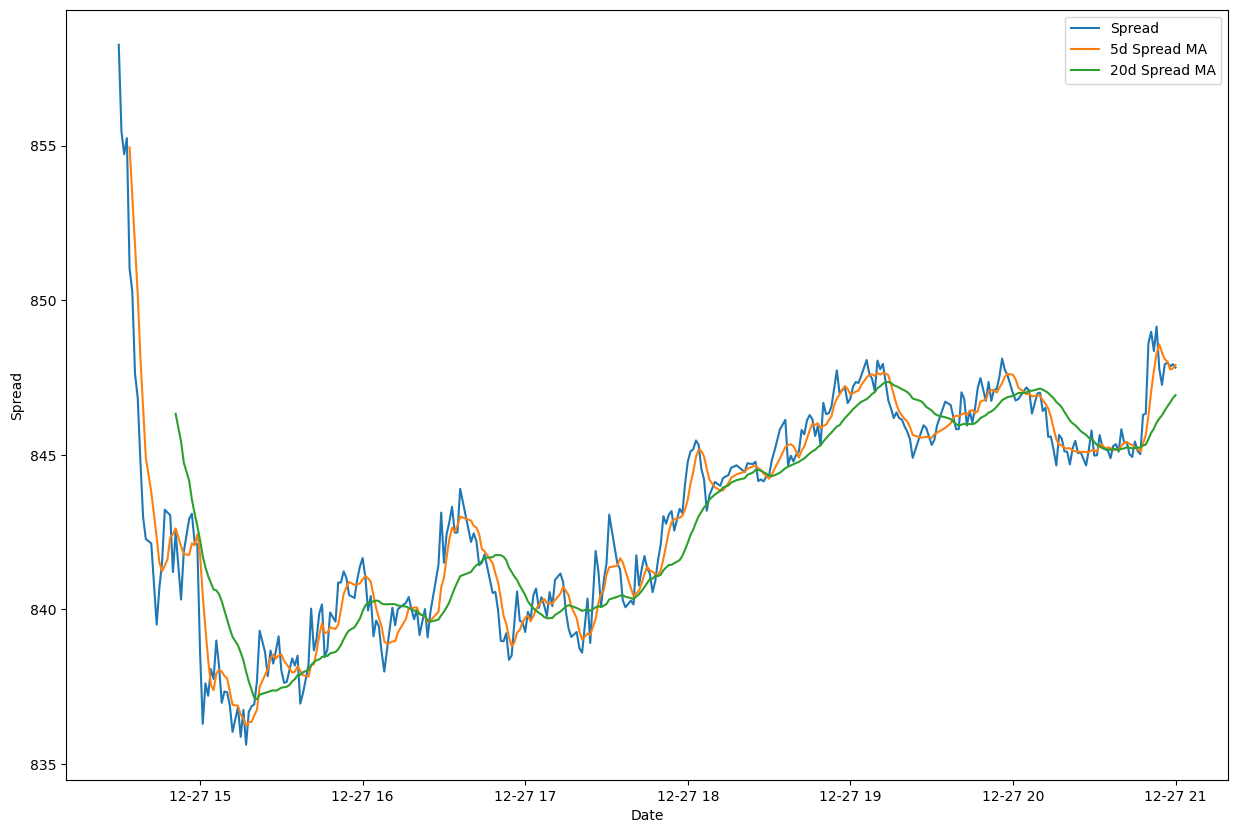

In [61]:
plt.figure(figsize=(15, 10))
spread_mavg5 = spread.rolling(window=5, center=False).mean()
spread_mavg20 = spread.rolling(window=20, center=False).mean()

std_20 = spread.rolling(window=20, center=False).std()
zscore_20_5 = (spread_mavg5 - spread_mavg20)/std_20

plt.plot(spread.index, spread.values)
plt.plot(spread_mavg5.index, spread_mavg5.values)
plt.plot(spread_mavg20.index, spread_mavg20.values)
plt.legend(['Spread', '5d Spread MA', '20d Spread MA'])
plt.xlabel('Date')
plt.ylabel('Spread')
plt.show()

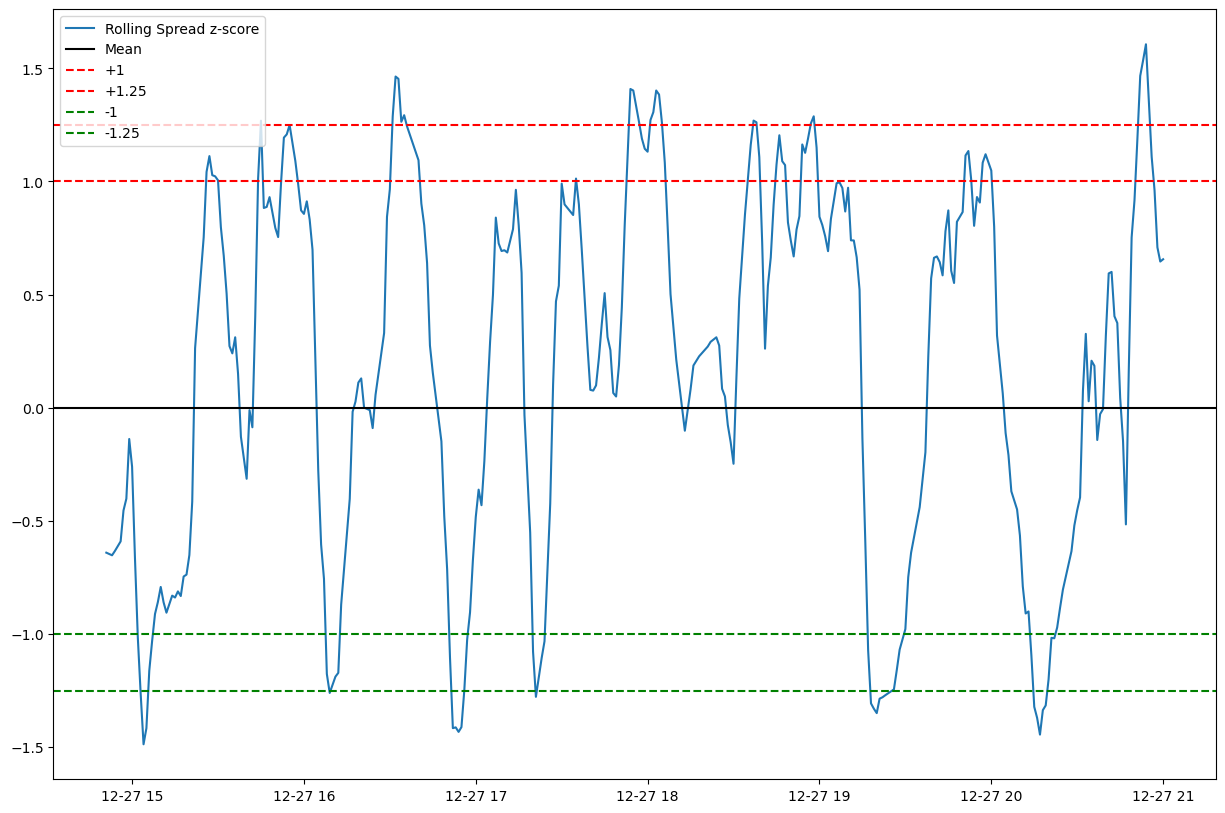

In [62]:
plt.figure(figsize=(15, 10))
plt.plot(zscore_20_5)
plt.axhline(0, color='black')
plt.axhline(1, color='red', linestyle='--')
plt.axhline(1.25, color='red', linestyle='--')
plt.axhline(-1, color='green', linestyle='--')
plt.axhline(-1.25, color='green', linestyle='--')
plt.legend(['Rolling Spread z-score', 'Mean', '+1','+1.25','-1','-1.25'])
plt.show()

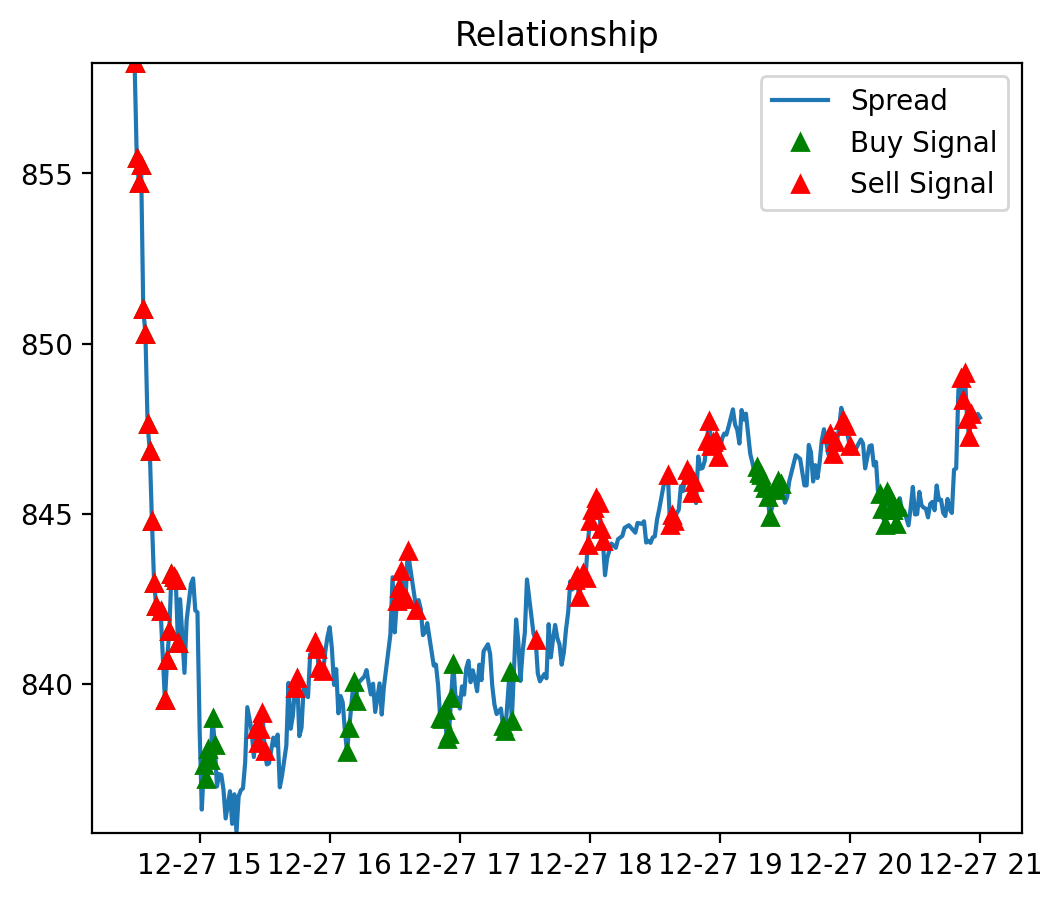

In [66]:
plt.figure(figsize=(6, 5), dpi=200)
plt.plot(spread)
buy = spread.copy()
sell = spread.copy()
buy[zscore_20_5>-1] = 0
sell[zscore_20_5<1] = 0

plt.plot(buy, color='g', linestyle='None', marker='^')
plt.plot(sell, color='r', linestyle='None', marker='^')

x1, x2, y1, y2 = plt.axis()
plt.axis((x1, x2, spread.min(), spread.max()))
plt.legend(['Spread', 'Buy Signal', 'Sell Signal'])
plt.title('Relationship')
plt.show()

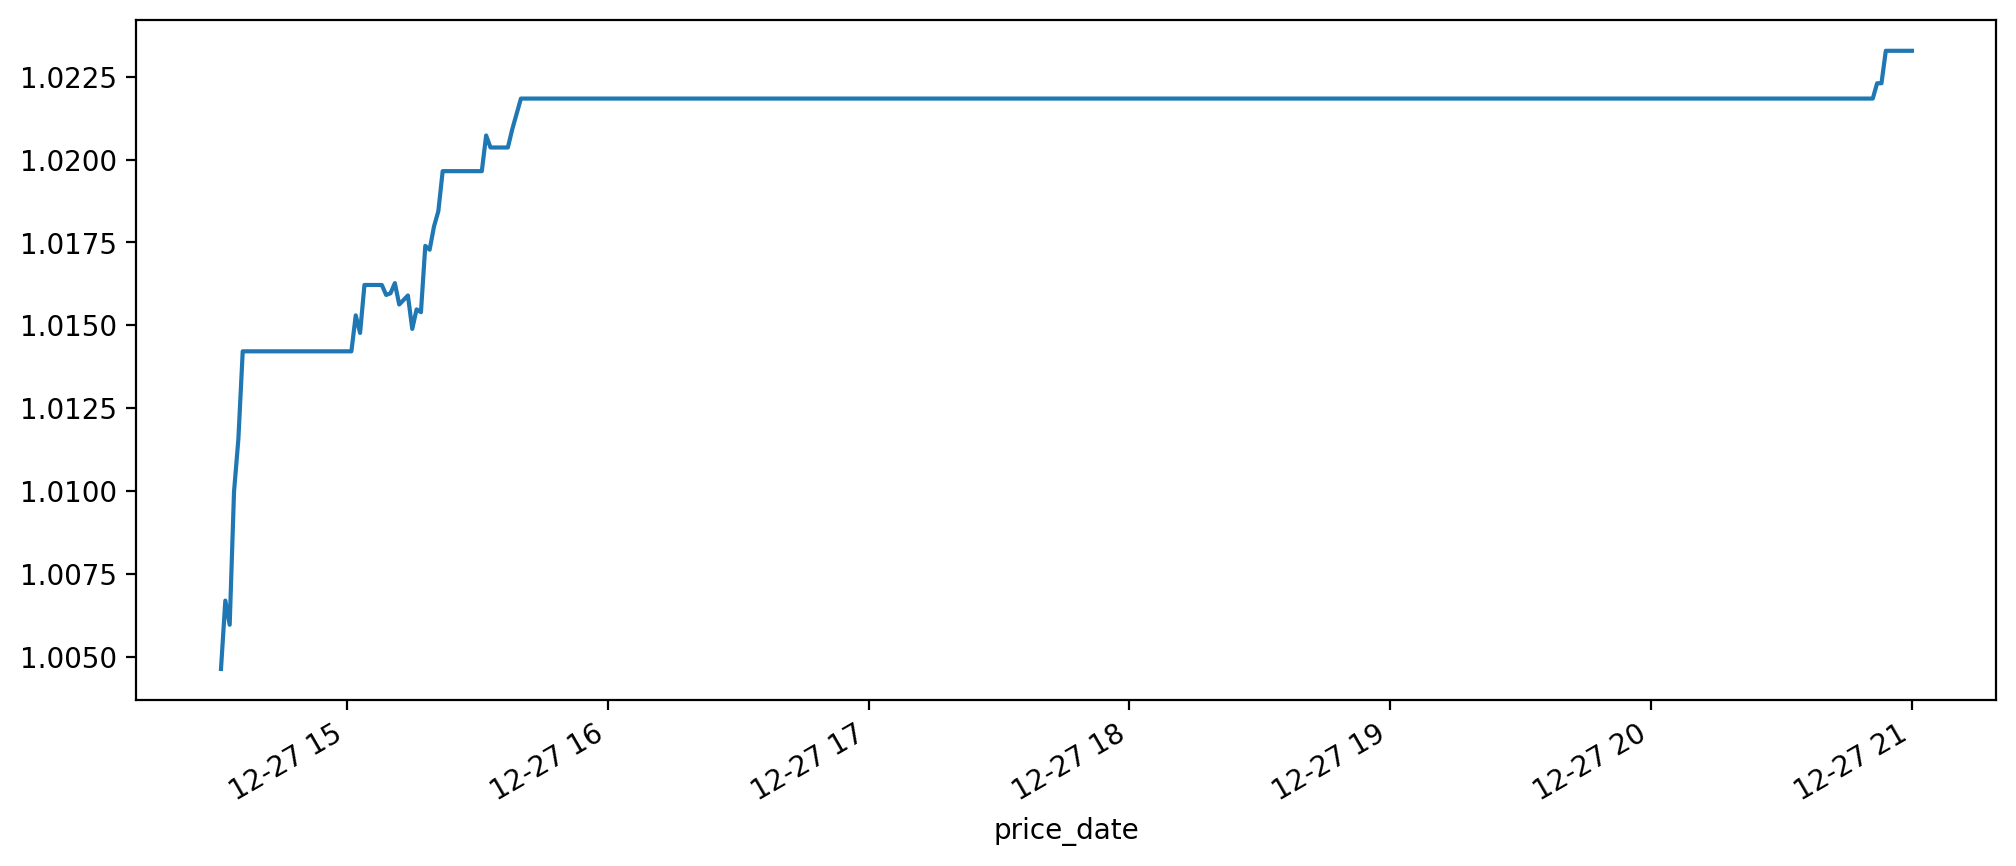

In [64]:
# Enter a long position if the z-score is less than -n_std
# Enter a short position if the z-score is greater than n_std
signal = np.where(zscore < -n_std, 1, np.where(zscore > n_std, -1, 0))
signal = pd.Series(signal, index=data.index)

# Calculate the daily returns
returns = stock_1.pct_change() - stock_2.pct_change()

# Calculate the strategy returns : # Shift the signal by one day to compute the returns
strategy_returns = signal.shift(1) * returns

# Calculate the cumulative returns
cumulative_returns = (1 + strategy_returns).cumprod()

# # Plot the cumulative returns
figs=(12,5)
plt.figure(figsize = figs, dpi=200)
cumulative_returns.plot()
plt.show()

In [68]:
def trade(signal, stock, portfolio, trade_perc=0.2):
    """
    signal = buy/sell
    portfolio:   dict --> {start_val: float, free_cash:float, stock: no.shares}
    trade_perc: 0-1 decimal. Perc of portfolio per trade
    """
    stock_price = get_stock_price(stock)
    
    if signal=='buy':
        if portfolio['free_cash'] == 0:
            print('No Cash')
        else:
            max_trade = portfolio['start_val']*trade_perc
            trade_amount = min(max_trade, portfolio['free_cash'])
            
            portfolio['free_cash'] -= trade_amount
            
            bought_shares = trade_amount/stock_price
            portfolio['stocks'][stock]+= portfolio['stocks'].get(stock, 0) + bought_shares
            
    if signal=='sell':
        owned_shares = portfolio['stocks'].get(stock, 0)
        portfolio['free_cash']+= owned_shares * stock_price
        
        portfolio['stocks'][stock] = 0

    return portfolio

def portfolio_value(portfolio):
    val = {}
    val['Total'] = portfolio['free_cash']
    val['breakdown']['free_cash'] = portfolio['free_cash']
    for key in portfolio['stocks']:
        stock_value = portfolio['stocks'][stock] * get_stock_price(key)
        val['Total'] +=  stock_value
        val['breakdown'][key] = stock_value
    return val

def get_stock_price(stock):
    return data.close.loc[date,s1]

In [72]:
date = '2024-12-27 14:33:00'
get_stock_price('AMD')

915.05

In [73]:
buy

price_date
2024-12-27 14:30:00    858.260
2024-12-27 14:31:00    855.455
2024-12-27 14:32:00    854.720
2024-12-27 14:33:00    855.240
2024-12-27 14:34:00    851.015
                        ...   
2024-12-27 20:56:00      0.000
2024-12-27 20:57:00      0.000
2024-12-27 20:58:00      0.000
2024-12-27 20:59:00      0.000
2024-12-27 21:00:00      0.000
Length: 342, dtype: float64